<a href="https://colab.research.google.com/github/mr-baraiya/Machine-Learning-Deep-Learning-hub/blob/main/Lab13/Lab13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 13

## Section 1: PyTorch



## Import Torch

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

In [7]:
pip install torch

### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: cuda


torch.Tensor

In [9]:
sample_input

tensor([[-0.4206, -0.2294,  0.4385,  0.3654, -0.1974,  0.6621, -0.6933,  0.0688,
         -0.5117,  0.8263]], device='cuda:0')

## Section 2: MNIST Project
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [10]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [11]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 546kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


In [12]:
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing One Image & Understanding Shapes

In [13]:
len(training_data)

60000

In [14]:
len(test_data)

10000

In [15]:
img, label = training_data[0]

In [16]:
img.shape

torch.Size([1, 28, 28])

In [17]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [18]:
img.squeeze().shape

torch.Size([28, 28])

## Display one Image in MatplotLib

In [19]:
import matplotlib.pyplot as plt

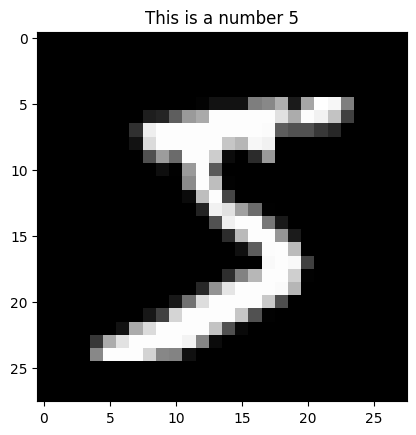

In [20]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"This is a number {label}")
plt.show()

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [21]:
img, label = training_data[1]

In [22]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [23]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),# Activation
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = SimpleNet()
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [24]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [26]:
def train():
    model.train()

    # Epoch Loop - Train for multiple epochs
    num_epochs = 5

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")

        for batch_No, (data, target) in enumerate(train_loader):

            output = model(data)

            loss = loss_fn(output, target)

            # Backpropagation
            optimizer.zero_grad()  # Clear old calculations
            loss.backward()        # Calculate gradients
            optimizer.step()       # Update weights

            if batch_No % 100 == 0:
                print(f"Batch {batch_No}: Loss = {loss.item():.4f}")

        print(f"Epoch {epoch + 1} completed!")

# Run training

In [27]:
train()


--- Epoch 1/5 ---
Batch 0: Loss = 2.3109
Batch 100: Loss = 0.4686
Batch 200: Loss = 0.3623
Batch 300: Loss = 0.3089
Batch 400: Loss = 0.4030
Batch 500: Loss = 0.2133
Batch 600: Loss = 0.2152
Batch 700: Loss = 0.3723
Batch 800: Loss = 0.1206
Batch 900: Loss = 0.1219
Epoch 1 completed!

--- Epoch 2/5 ---
Batch 0: Loss = 0.1617
Batch 100: Loss = 0.2188
Batch 200: Loss = 0.1167
Batch 300: Loss = 0.1038
Batch 400: Loss = 0.2468
Batch 500: Loss = 0.0761
Batch 600: Loss = 0.0746
Batch 700: Loss = 0.2103
Batch 800: Loss = 0.1508
Batch 900: Loss = 0.2094
Epoch 2 completed!

--- Epoch 3/5 ---
Batch 0: Loss = 0.0994
Batch 100: Loss = 0.1422
Batch 200: Loss = 0.0838
Batch 300: Loss = 0.0246
Batch 400: Loss = 0.1527
Batch 500: Loss = 0.0646
Batch 600: Loss = 0.0720
Batch 700: Loss = 0.0325
Batch 800: Loss = 0.0911
Batch 900: Loss = 0.0537
Epoch 3 completed!

--- Epoch 4/5 ---
Batch 0: Loss = 0.0349
Batch 100: Loss = 0.0733
Batch 200: Loss = 0.0486
Batch 300: Loss = 0.0429
Batch 400: Loss = 0.1202


In [28]:
def test():
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)

            prediction = output.argmax(dim=1)

            correct += (prediction == target).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.1%}")

test()

Test Accuracy: 97.4%


In [29]:
def predict_image(index):
  model.eval()
  img, actual_label = test_data[index]
  #
  input_tensor = img.unsqueeze(0)
  with torch.no_grad():
    logits = model(input_tensor)
    predicted_label = logits.argmax(dim=1).item()

  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(f"Actual : {actual_label} | Predicted : {predicted_label}")
  plt.axis("off")
  plt.show()

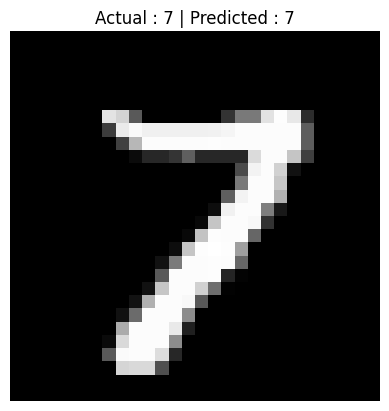

In [37]:
# 0to 9999
predict_image(34)

In [38]:
for name, param in model.named_parameters():
    print(f"{name} : {param.shape}")

layers.0.weight : torch.Size([128, 784])
layers.0.bias : torch.Size([128])
layers.2.weight : torch.Size([10, 128])
layers.2.bias : torch.Size([10])


In [39]:
10770

10770